# Customer Behavior EDA

This notebook explores acquisition, engagement, purchase, service-interaction, and retention signals to understand the behavioral patterns associated with customer value, engagement, and retention.

The analysis uses the generated synthetic raw data and focuses on behavioral structure rather than prediction.

A dedicated service interaction section is included to capture complaints, refunds, support load, and issue resolution quality as part of the customer health picture.


## 1. Data Overview and Quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/Users/qiaodou/Desktop/onemoreclass-churn-intelligence")
os.chdir(PROJECT_ROOT)

print("Working directory:", os.getcwd())

Working directory: /Users/qiaodou/Desktop/onemoreclass-churn-intelligence


In [3]:
customers = pd.read_csv('data/raw/customers.csv', parse_dates=['signup_date'])
courses = pd.read_csv('data/raw/courses.csv')
activities = pd.read_csv('data/raw/activities.csv', parse_dates=['activity_date'])
transactions = pd.read_csv('data/raw/transactions.csv', parse_dates=['transaction_date'])
interactions = pd.read_csv('data/raw/interactions.csv', parse_dates=['interaction_date'])

print('customers:', customers.shape)
print('activities:', activities.shape)
print('transactions:', transactions.shape)
print('interactions:', interactions.shape)
print('customer columns:', list(customers.columns))
print('activity columns:', list(activities.columns))
print(customers.head())


customers: (5000, 9)
activities: (900000, 8)
transactions: (5513, 14)
interactions: (8674, 9)
customer columns: ['customer_id', 'signup_date', 'university', 'country', 'age', 'class_year', 'academic_group', 'plan_type', 'acquisition_channel']
activity columns: ['customer_id', 'activity_date', 'login_count', 'videos_watched', 'minutes_watched', 'courses_started', 'courses_completed', 'assignments_completed']
   customer_id signup_date university country  age class_year  \
0       100001  2025-02-02      XJTLU   China   20     Year 2   
1       100002  2025-10-10      XJTLU   China   20     Year 3   
2       100003  2025-08-27        UoL      UK   18     Year 1   
3       100004  2025-06-10        UoL      UK   20     Year 2   
4       100005  2025-06-08      XJTLU   China   20     Year 3   

                 academic_group plan_type acquisition_channel  
0                   Engineering     Basic              Social  
1          Business & Economics   Premium             Organic  
2     

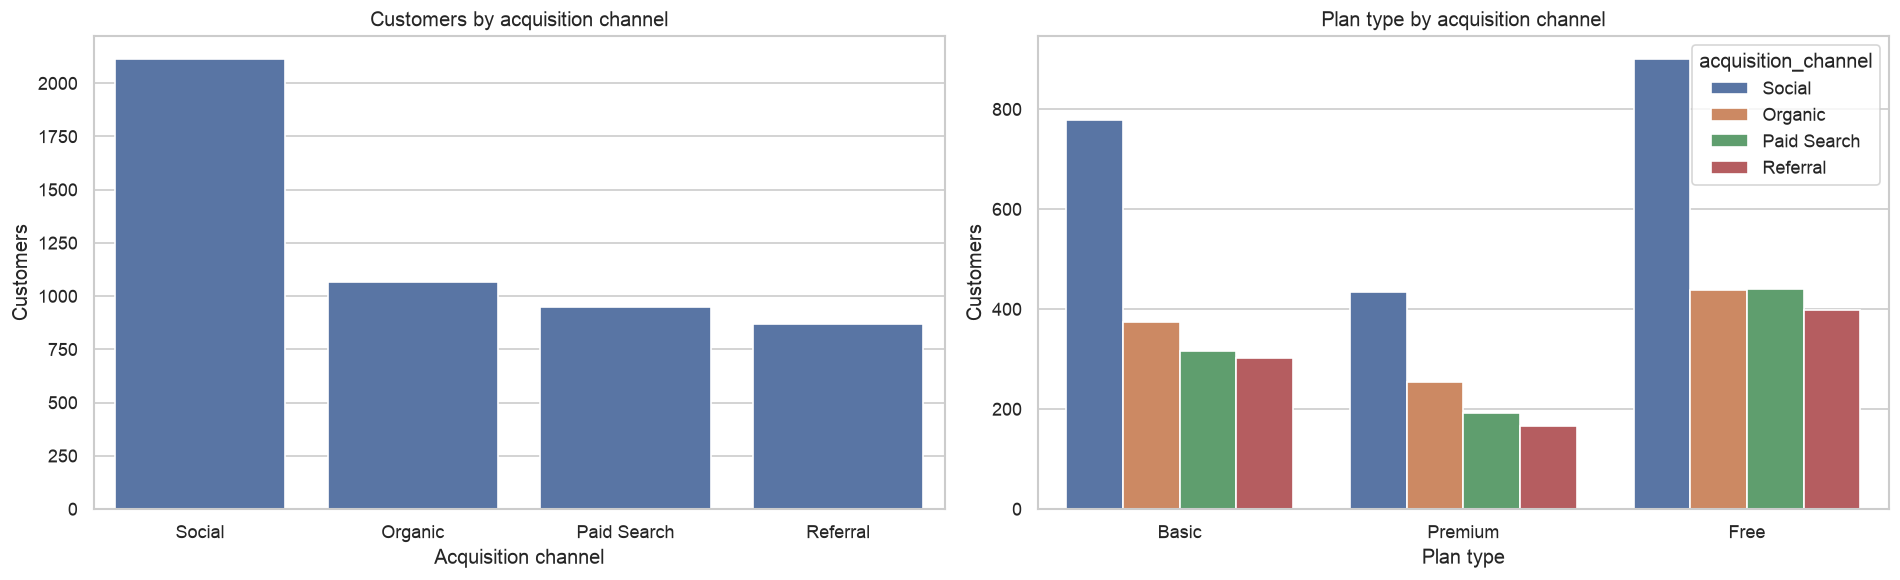

  signup_month acquisition_channel  customer_count
0      2025-01             Organic              81
1      2025-01         Paid Search              72
2      2025-01            Referral              56
3      2025-01              Social             187
4      2025-02             Organic              85
5      2025-02         Paid Search              74
6      2025-02            Referral              70
7      2025-02              Social             196
8      2025-03             Organic              87
9      2025-03         Paid Search              81


In [4]:
customers['signup_month'] = customers['signup_date'].dt.to_period('M').astype(str)

acquisition_summary = customers.groupby(['signup_month', 'acquisition_channel']).size().reset_index(name='customer_count')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=customers, x='acquisition_channel', order=customers['acquisition_channel'].value_counts().index, ax=axes[0])
axes[0].set_title('Customers by acquisition channel')
axes[0].set_xlabel('Acquisition channel')
axes[0].set_ylabel('Customers')

sns.countplot(data=customers, x='plan_type', hue='acquisition_channel', ax=axes[1])
axes[1].set_title('Plan type by acquisition channel')
axes[1].set_xlabel('Plan type')
axes[1].set_ylabel('Customers')
plt.tight_layout()
plt.show()

print(acquisition_summary.head(10))


       customer_id  total_logins  total_minutes  total_videos  \
count      5000.00       5000.00        5000.00       5000.00   
mean     102500.50        276.19        6611.44        550.97   
std        1443.52         98.72        2157.24        179.24   
min      100001.00         33.00        1423.72        122.00   
25%      101250.75        202.75        5027.00        420.00   
50%      102500.50        276.00        6599.87        551.00   
75%      103750.25        347.00        8167.88        681.00   
max      105000.00        581.00       13830.64       1103.00   

       total_courses_started  total_assignments  
count                5000.00            5000.00  
mean                   24.62              67.24  
std                     9.00              28.34  
min                     1.00               0.00  
25%                    18.00              46.00  
50%                    24.00              67.00  
75%                    31.00              88.00  
max           

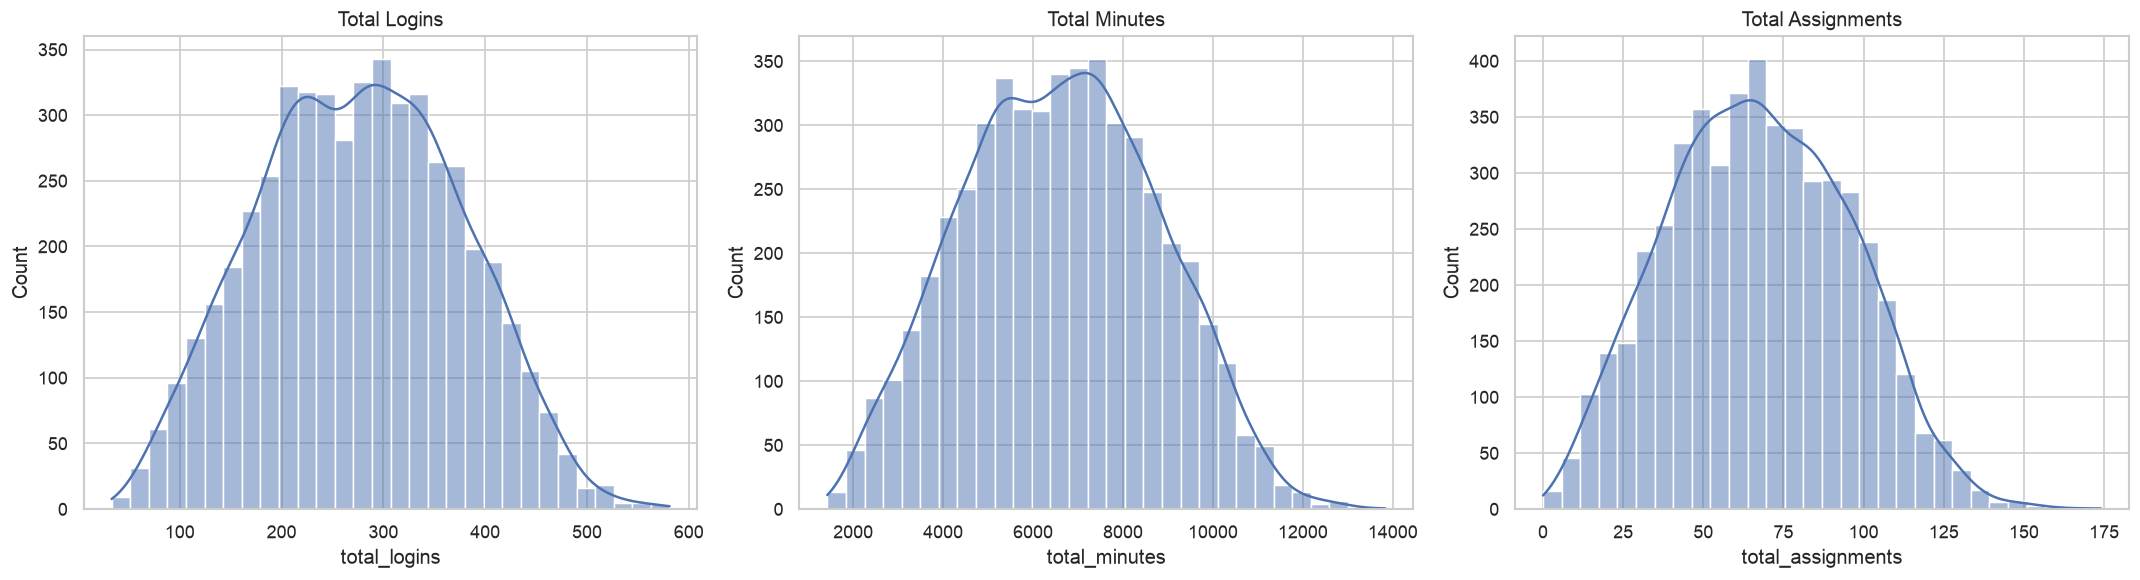

In [5]:
activity_summary = activities.groupby('customer_id').agg(
    total_logins=('login_count', 'sum'),
    total_minutes=('minutes_watched', 'sum'),
    total_videos=('videos_watched', 'sum'),
    total_courses_started=('courses_started', 'sum'),
    total_assignments=('assignments_completed', 'sum')
).reset_index()

print(activity_summary.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['total_logins', 'total_minutes', 'total_assignments']):
    sns.histplot(activity_summary[col], bins=30, kde=True, ax=ax)
    ax.set_title(col.replace('_', ' ').title())
plt.tight_layout()
plt.show()


Currency mix by customer:
primary_currency
RMB    2321
GBP     888
Name: count, dtype: int64

Spend summary by currency:
                 total_spend                                               \
                       count    mean     std   min     25%     50%    75%   
primary_currency                                                            
GBP                    888.0  312.40  296.26  47.2   99.00  161.12  499.0   
RMB                   2321.0  507.42  466.03  79.2  169.15  272.10  799.0   

                         avg_order_value          ...                 \
                     max           count    mean  ...     75%    max   
primary_currency                                  ...                  
GBP               1567.0           888.0  185.76  ...  236.06  699.0   
RMB               3434.0          2321.0  309.43  ...  434.05  999.0   

                 max_order_value                                             \
                           count    mean     std   mi

/var/folders/_j/919l95c91_94hh77kq2l8wp00000gn/T/ipykernel_50947/3186043654.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Currency')
/var/folders/_j/919l95c91_94hh77kq2l8wp00000gn/T/ipykernel_50947/3186043654.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Currency')
/var/folders/_j/919l95c91_94hh77kq2l8wp00000gn/T/ipykernel_50947/3186043654.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Currency')


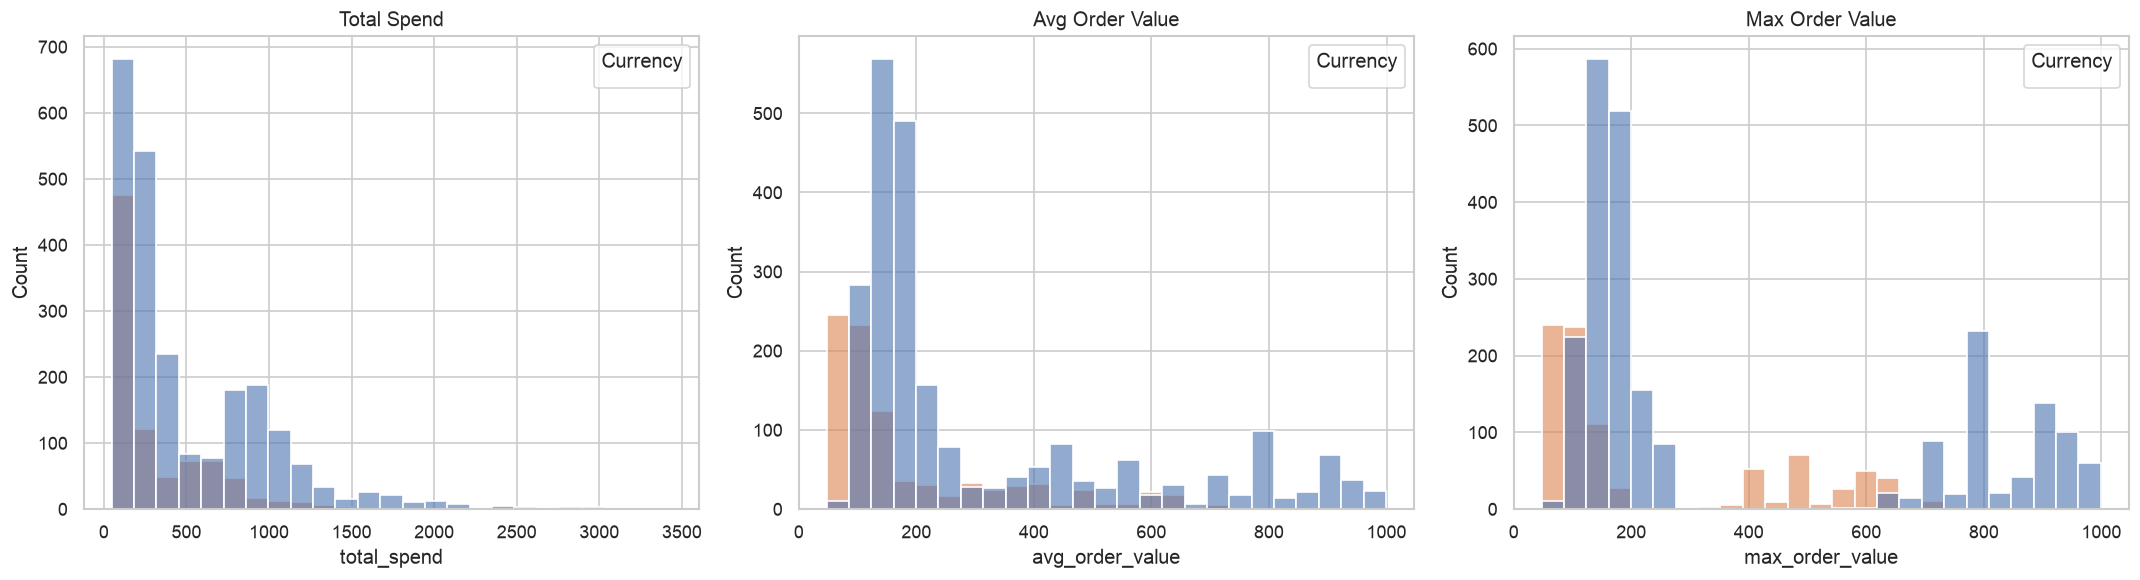

In [6]:
transactions['promotion_tier'] = transactions['promotion_tier'].fillna('None')

paid_transactions = transactions[transactions['payment_status'] == 'Paid'].copy()

attempt_summary = (
    transactions.groupby('customer_id')
    .agg(
        transaction_attempts=('transaction_id', 'count'),
        failed_payment_rate=('payment_status', lambda s: (s != 'Paid').mean()),
        successful_transactions=('payment_status', lambda s: (s == 'Paid').sum())
    )
    .reset_index()
)

paid_customer_currency = (
    paid_transactions.groupby('customer_id')['currency']
    .agg(lambda s: s.mode().iloc[0])
    .rename('primary_currency')
    .reset_index()
)

transaction_summary = (
    paid_transactions.merge(paid_customer_currency, on='customer_id', how='left')
    .loc[lambda d: d['currency'] == d['primary_currency']]
    .groupby('customer_id')
    .agg(
        total_transactions=('transaction_id', 'count'),
        total_spend=('final_amount', 'sum'),
        avg_order_value=('final_amount', 'mean'),
        max_order_value=('final_amount', 'max'),
        live_purchase_share=('delivery_mode', lambda s: (s == 'Live').mean()),
        promotion_usage=('promotion_tier', lambda s: (s != 'None').mean()),
        primary_currency=('currency', 'first')
    )
    .reset_index()
)

transaction_summary = transaction_summary.merge(attempt_summary, on='customer_id', how='left').fillna(0)

print('Currency mix by customer:')
print(transaction_summary['primary_currency'].value_counts())

print('\nSpend summary by currency:')
print(transaction_summary.groupby('primary_currency')[['total_spend', 'avg_order_value', 'max_order_value']].describe().round(2))

print('\nPurchase attempt / conversion summary:')
print(transaction_summary[['transaction_attempts', 'successful_transactions', 'failed_payment_rate']].describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['total_spend', 'avg_order_value', 'max_order_value']):
    sns.histplot(
        data=transaction_summary,
        x=col,
        hue='primary_currency',
        bins=25,
        multiple='layer',
        alpha=0.6,
        ax=ax
    )
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(title='Currency')
plt.tight_layout()
plt.show()


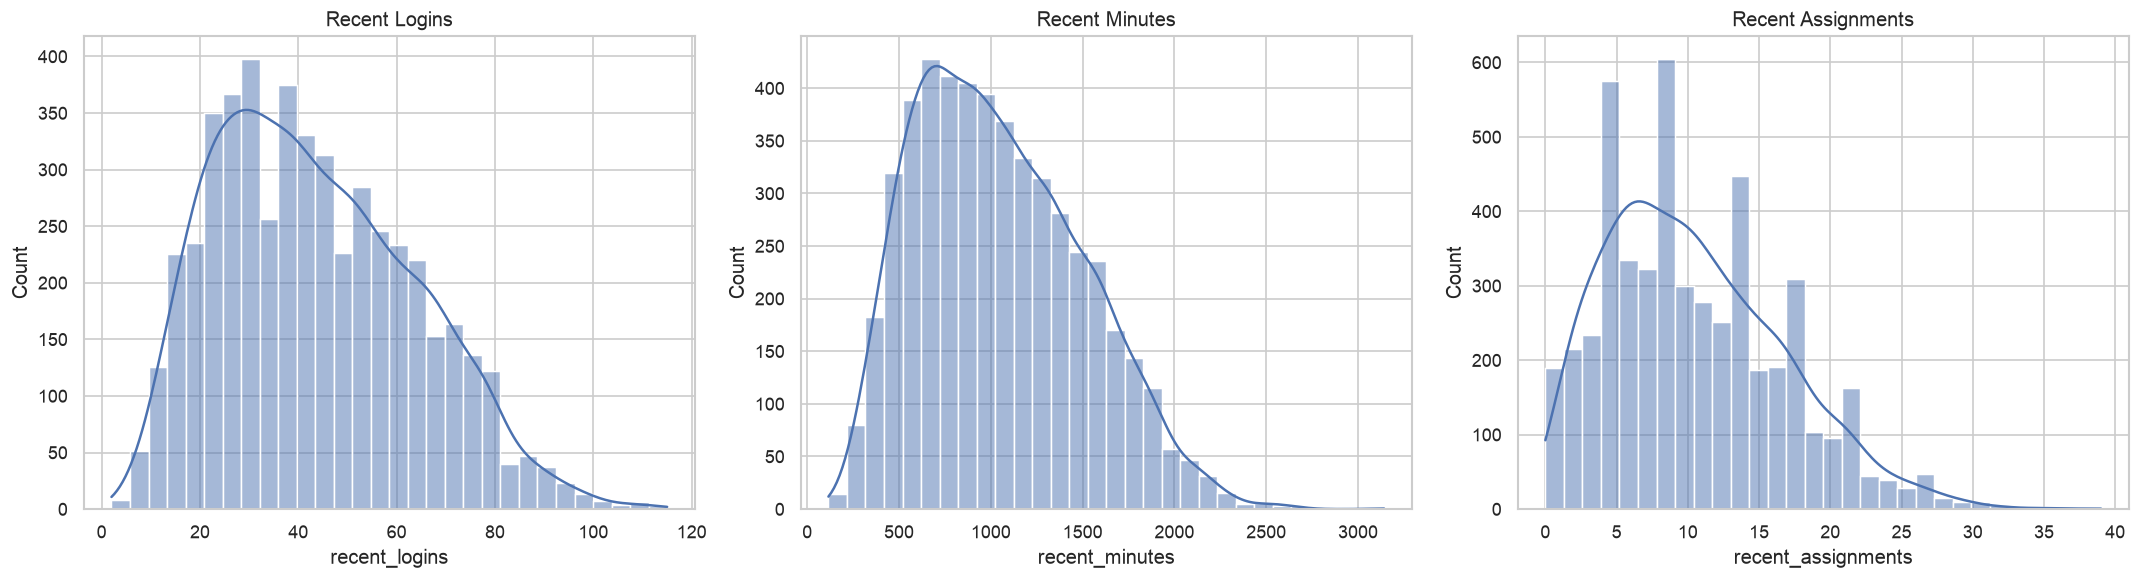

       recent_logins  prior_logins  login_drop_rate  recent_minutes  \
count      5000.0000     5000.0000        5000.0000       5000.0000   
mean         43.4058       44.3516           0.0011       1046.0585   
std          20.2462       19.2703           0.2826        454.9693   
min           2.0000        2.0000          -6.5000        115.3800   
25%          27.0000       29.0000          -0.1429        683.7350   
50%          41.0000       43.0000           0.0253        991.4350   
75%          58.0000       58.0000           0.1751       1361.6000   
max         115.0000      123.0000           0.7667       3141.7100   

       prior_minutes  minutes_drop_rate  recent_assignments  \
count      5000.0000          5000.0000           5000.0000   
mean       1065.7289            -0.0133             10.4342   
std         436.9778             0.3063              6.2417   
min         148.8600            -2.0083              0.0000   
25%         723.6175            -0.1697      

In [7]:
max_date = activities['activity_date'].max()
recent_start = max_date - pd.Timedelta(days=29)
prior_end = recent_start - pd.Timedelta(days=1)
prior_start = prior_end - pd.Timedelta(days=29)

recent_activity = activities[
    (activities['activity_date'] >= recent_start) &
    (activities['activity_date'] <= max_date)
].groupby('customer_id').agg(
    recent_logins=('login_count', 'sum'),
    recent_minutes=('minutes_watched', 'sum'),
    recent_assignments=('assignments_completed', 'sum')
).reset_index()

prior_activity = activities[
    (activities['activity_date'] >= prior_start) &
    (activities['activity_date'] <= prior_end)
].groupby('customer_id').agg(
    prior_logins=('login_count', 'sum'),
    prior_minutes=('minutes_watched', 'sum'),
    prior_assignments=('assignments_completed', 'sum')
).reset_index()

retention = customers[['customer_id', 'signup_date']].merge(
    recent_activity,
    on='customer_id',
    how='left'
).merge(
    prior_activity,
    on='customer_id',
    how='left'
).fillna(0)

def safe_decline_rate(prior, recent):
    return np.where(
        prior > 0,
        (prior - recent) / prior,
        np.where(recent == 0, 0.0, -1.0),
    )

retention["login_drop_rate"] = safe_decline_rate(
    retention["prior_logins"],
    retention["recent_logins"],
)

retention["minutes_drop_rate"] = safe_decline_rate(
    retention["prior_minutes"],
    retention["recent_minutes"],
)

retention["assignment_drop_rate"] = safe_decline_rate(
    retention["prior_assignments"],
    retention["recent_assignments"],
)

retention['customer_age_days'] = (max_date - retention['signup_date']).dt.days

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['recent_logins', 'recent_minutes', 'recent_assignments']):
    sns.histplot(retention[col], bins=30, kde=True, ax=ax)
    ax.set_title(col.replace('_', ' ').title())
plt.tight_layout()
plt.show()

print(retention[
    ['recent_logins', 'prior_logins', 'login_drop_rate',
     'recent_minutes', 'prior_minutes', 'minutes_drop_rate',
     'recent_assignments', 'prior_assignments', 'assignment_drop_rate']
].describe().round(4))

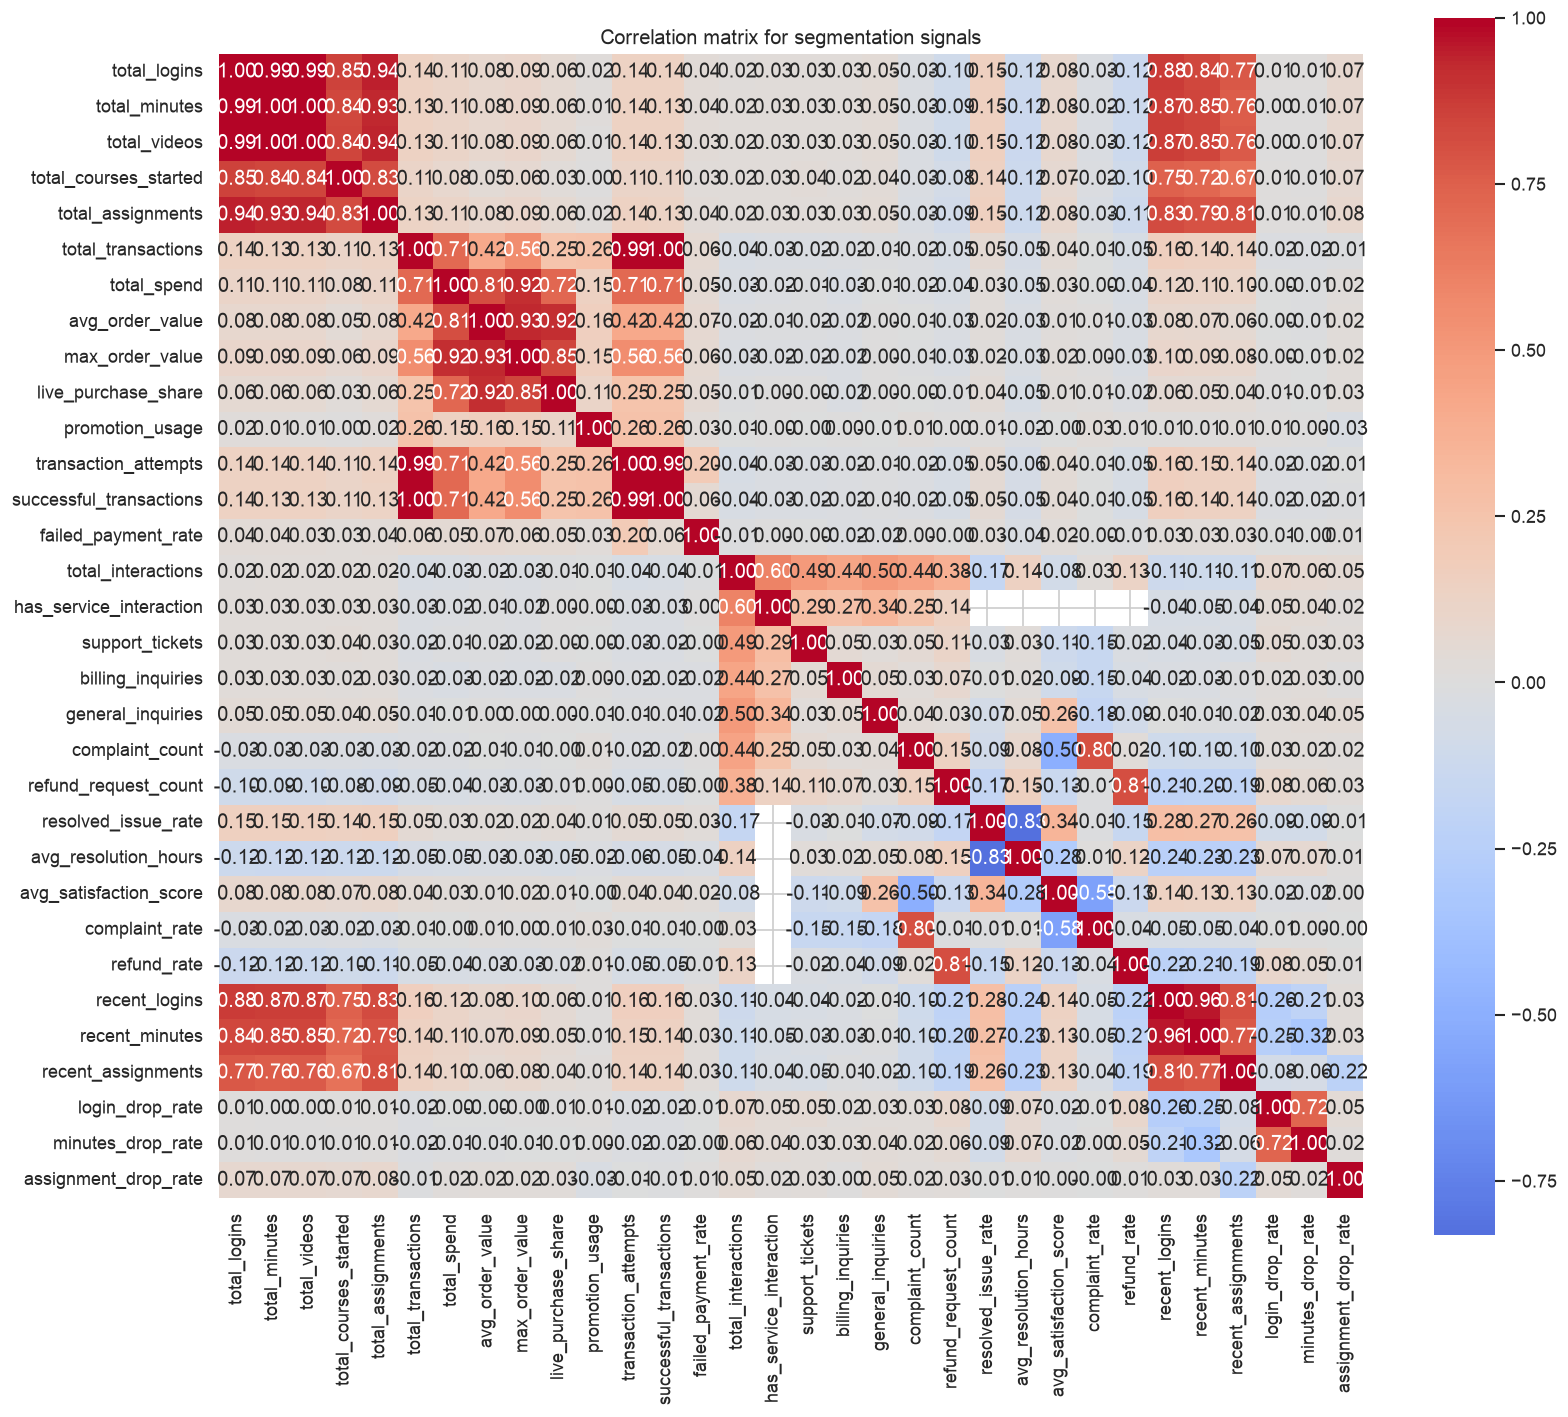

       total_logins  total_minutes  total_videos  total_courses_started  \
count       5000.00        5000.00       5000.00                5000.00   
mean         276.19        6611.44        550.97                  24.62   
std           98.72        2157.24        179.24                   9.00   
min           33.00        1423.72        122.00                   1.00   
25%          202.75        5027.00        420.00                  18.00   
50%          276.00        6599.87        551.00                  24.00   
75%          347.00        8167.88        681.00                  31.00   
max          581.00       13830.64       1103.00                  57.00   

       total_assignments  total_transactions  total_spend  avg_order_value  \
count            5000.00             5000.00      5000.00          5000.00   
mean               67.24                1.06       291.03           176.63   
std                28.34                1.07       410.53           230.27   
min         

In [8]:
customer_base = customers[['customer_id', 'university', 'country', 'plan_type', 'acquisition_channel', 'class_year']].copy()

interaction_summary = interactions.groupby('customer_id').agg(
    total_interactions=('interaction_id', 'count'),
    support_tickets=('interaction_type', lambda s: (s == 'support_ticket').sum()),
    billing_inquiries=('interaction_type', lambda s: (s == 'billing_inquiry').sum()),
    general_inquiries=('interaction_type', lambda s: (s == 'general_inquiry').sum()),
    complaint_count=('complaint_flag', 'sum'),
    refund_request_count=('refund_request_flag', 'sum'),
    resolved_issue_rate=('issue_resolved', 'mean'),
    avg_resolution_hours=('resolution_time_hours', 'mean'),
    avg_satisfaction_score=('satisfaction_score', 'mean'),
    complaint_rate=('complaint_flag', 'mean'),
    refund_rate=('refund_request_flag', 'mean')
).reset_index()

feature_frame = (
    customer_base
    .merge(activity_summary, on='customer_id', how='left')
    .merge(transaction_summary, on='customer_id', how='left')
    .merge(interaction_summary, on='customer_id', how='left')
    .merge(retention, on='customer_id', how='left')
)

feature_frame['has_service_interaction'] = (
    feature_frame['total_interactions'].fillna(0) > 0
).astype(int)

zero_fill_cols = [
    'total_logins', 'total_minutes', 'total_videos', 'total_courses_started', 'total_assignments',
    'total_transactions', 'total_spend', 'avg_order_value', 'max_order_value', 'live_purchase_share',
    'promotion_usage', 'transaction_attempts', 'successful_transactions', 'failed_payment_rate',
    'total_interactions', 'support_tickets', 'billing_inquiries', 'general_inquiries',
    'complaint_count', 'refund_request_count',
    'recent_logins', 'recent_minutes', 'recent_assignments',
    'login_drop_rate', 'minutes_drop_rate', 'assignment_drop_rate'
]

feature_frame[zero_fill_cols] = feature_frame[zero_fill_cols].fillna(0)

numeric_cols = [
    'total_logins', 'total_minutes', 'total_videos', 'total_courses_started', 'total_assignments',
    'total_transactions', 'total_spend', 'avg_order_value', 'max_order_value', 'live_purchase_share',
    'promotion_usage', 'transaction_attempts', 'successful_transactions', 'failed_payment_rate',
    'total_interactions', 'has_service_interaction', 'support_tickets', 'billing_inquiries', 'general_inquiries',
    'complaint_count', 'refund_request_count', 'resolved_issue_rate', 'avg_resolution_hours',
    'avg_satisfaction_score', 'complaint_rate', 'refund_rate',
    'recent_logins', 'recent_minutes', 'recent_assignments',
    'login_drop_rate', 'minutes_drop_rate', 'assignment_drop_rate'
]

corr = feature_frame[numeric_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix for segmentation signals')
plt.tight_layout()
plt.show()

print(feature_frame[numeric_cols].describe().round(2))


Interaction type mix:
interaction_type
general_inquiry    2149
course_feedback    1823
support_ticket     1630
billing_inquiry    1400
complaint          1234
refund_request      438
Name: count, dtype: int64

Interaction summary by customer:
       total_interactions  complaint_count  refund_request_count  \
count            3945.000         3945.000              3945.000   
mean                2.199            0.313                 0.111   
std                 1.342            0.567                 0.365   
min                 1.000            0.000                 0.000   
25%                 1.000            0.000                 0.000   
50%                 2.000            0.000                 0.000   
75%                 3.000            1.000                 0.000   
max                11.000            4.000                 3.000   

       resolved_issue_rate  avg_resolution_hours  avg_satisfaction_score  
count             2827.000              2827.000                3945.

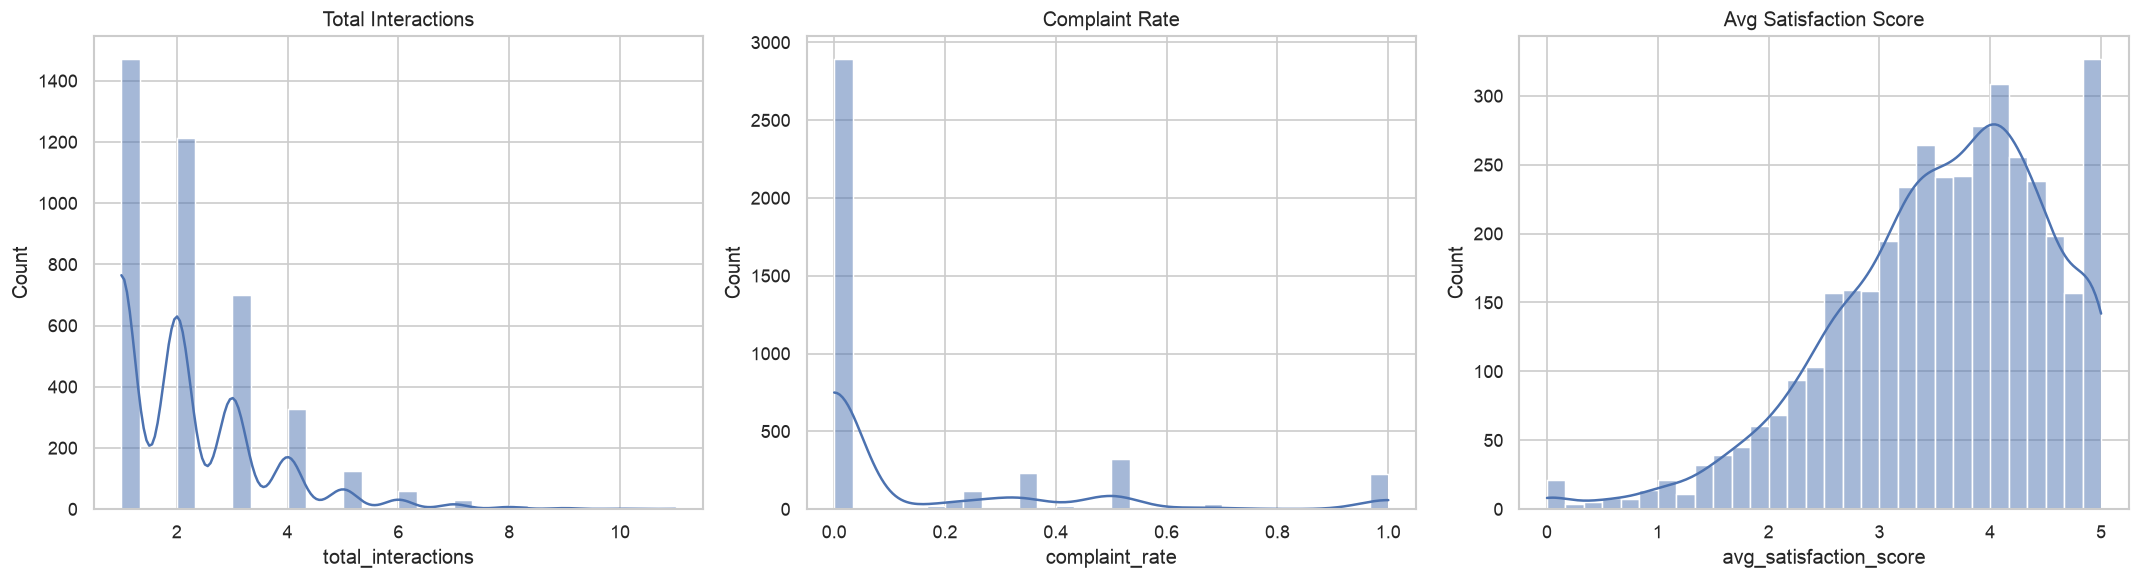


Issue-case resolution quality:
                  issue_count  resolved_rate  avg_resolution_hours  \
interaction_type                                                     
complaint                1234          0.526                35.604   
refund_request            438          0.379                45.783   

                  avg_satisfaction  
interaction_type                    
complaint                    1.722  
refund_request               3.007  


In [9]:
print('Interaction type mix:')
print(interactions['interaction_type'].value_counts())

print('\nInteraction summary by customer:')
print(interaction_summary[['total_interactions', 'complaint_count', 'refund_request_count', 'resolved_issue_rate', 'avg_resolution_hours', 'avg_satisfaction_score']].describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['total_interactions', 'complaint_rate', 'avg_satisfaction_score']):
    sns.histplot(interaction_summary[col], bins=30, kde=True, ax=ax)
    ax.set_title(col.replace('_', ' ').title())
plt.tight_layout()
plt.show()

issue_df = interactions[(interactions['complaint_flag'] == 1) | (interactions['refund_request_flag'] == 1)].copy()
if not issue_df.empty:
    print('\nIssue-case resolution quality:')
    print(issue_df.groupby('interaction_type').agg(
        issue_count=('interaction_id', 'count'),
        resolved_rate=('issue_resolved', 'mean'),
        avg_resolution_hours=('resolution_time_hours', 'mean'),
        avg_satisfaction=('satisfaction_score', 'mean')
    ).round(3))


In [10]:
print('Duplicate rows in customers:', customers.duplicated().sum())
print('Duplicate rows in activities:', activities.duplicated().sum())
print('Duplicate rows in transactions:', transactions.duplicated().sum())
print('Duplicate rows in interactions:', interactions.duplicated().sum())

print('Missing values by table:')
print(customers.isna().sum().sort_values(ascending=False).head())
print(activities.isna().sum().sort_values(ascending=False).head())
print(transactions.isna().sum().sort_values(ascending=False).head())
print('Quality check complete.')


Duplicate rows in customers: 0
Duplicate rows in activities: 0
Duplicate rows in transactions: 0
Duplicate rows in interactions: 0
Missing values by table:
customer_id    0
signup_date    0
university     0
country        0
age            0
dtype: int64
customer_id        0
activity_date      0
login_count        0
videos_watched     0
minutes_watched    0
dtype: int64
transaction_id      0
customer_id         0
transaction_date    0
purchase_period     0
course_id           0
dtype: int64
Quality check complete.



The following analysis examines how acquisition,
engagement, purchase behavior, service experience,
and recent behavioral changes are associated with
customer value and retention risk.

This section is designed to move from descriptive segmentation
toward behavioral interpretation: which signals best explain
why customers are more valuable, more fragile, or more likely
to decline.


## 2. Customer Behavior Overview

### 2.1 Acquisition


In [11]:
# =========================================================
# Acquisition Channel Quality
# =========================================================

# Customer-level paid purchase indicator
feature_frame["has_paid_purchase"] = (
    feature_frame["successful_transactions"] > 0
).astype(int)


# ---------------------------------------------------------
# 1. Summary table by acquisition channel
# ---------------------------------------------------------

acquisition_quality = (
    feature_frame
    .groupby("acquisition_channel")
    .agg(
        customers=("customer_id", "count"),

        # Engagement
        avg_recent_logins=("recent_logins", "mean"),
        avg_recent_minutes=("recent_minutes", "mean"),
        avg_recent_assignments=("recent_assignments", "mean"),

        # Purchase
        paid_conversion_rate=("has_paid_purchase", "mean"),
        avg_successful_transactions=("successful_transactions", "mean"),

        # Retention / behavioral trend
        avg_login_drop_rate=("login_drop_rate", "mean"),
        avg_minutes_drop_rate=("minutes_drop_rate", "mean"),
        avg_assignment_drop_rate=("assignment_drop_rate", "mean"),
    )
    .sort_values(
        "paid_conversion_rate",
        ascending=False
    )
)

print("\n=== Acquisition Channel Quality ===")
print(acquisition_quality.round(3))


=== Acquisition Channel Quality ===
                     customers  avg_recent_logins  avg_recent_minutes  \
acquisition_channel                                                     
Referral                   867             44.002            1060.193   
Social                    2115             43.678            1054.119   
Organic                   1068             42.519            1022.251   
Paid Search                950             43.253            1041.977   

                     avg_recent_assignments  paid_conversion_rate  \
acquisition_channel                                                 
Referral                             10.572                 0.654   
Social                               10.474                 0.649   
Organic                              10.279                 0.639   
Paid Search                          10.395                 0.618   

                     avg_successful_transactions  avg_login_drop_rate  \
acquisition_channel                 

### 2.2 Engagement


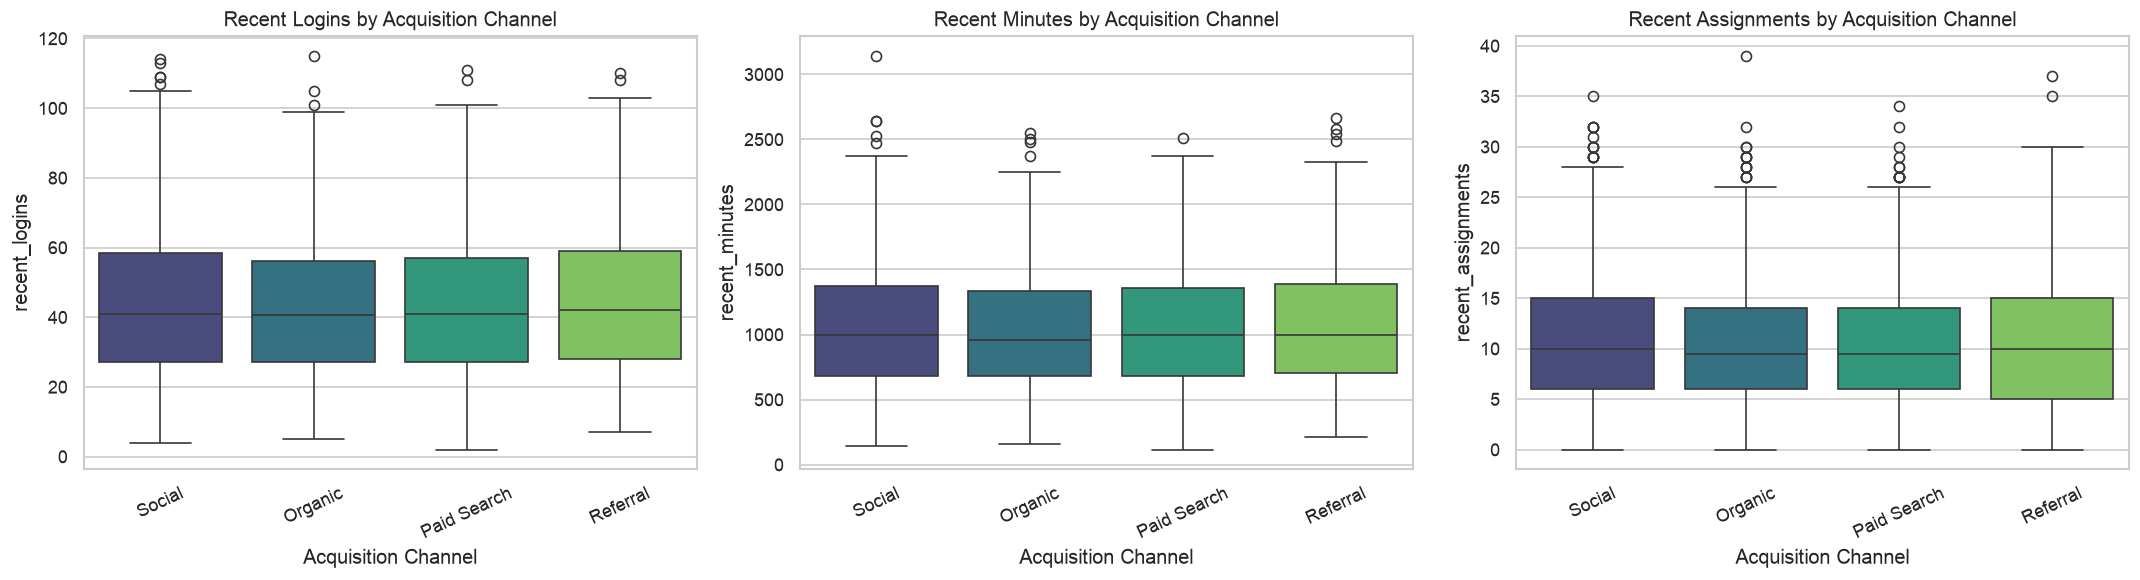

In [12]:
# ---------------------------------------------------------
# 2. Engagement by acquisition channel
# ---------------------------------------------------------

engagement_metrics = [
    "recent_logins",
    "recent_minutes",
    "recent_assignments",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, metric in zip(
    axes,
    engagement_metrics
):

    sns.boxplot(
        data=feature_frame,
        x="acquisition_channel",
        y=metric,
        hue="acquisition_channel",
        palette="viridis",
        legend=False,
        ax=ax
    )

    ax.set_title(
        f"{metric.replace('_', ' ').title()} by Acquisition Channel"
    )

    ax.set_xlabel(
        "Acquisition Channel"
    )

    ax.tick_params(
        axis="x",
        rotation=25
    )

plt.tight_layout()
plt.show()

### 2.3 Monetization



Paid conversion rate by acquisition channel:
  acquisition_channel  paid_conversion_rate
0            Referral                 0.654
1              Social                 0.649
2             Organic                 0.639
3         Paid Search                 0.618


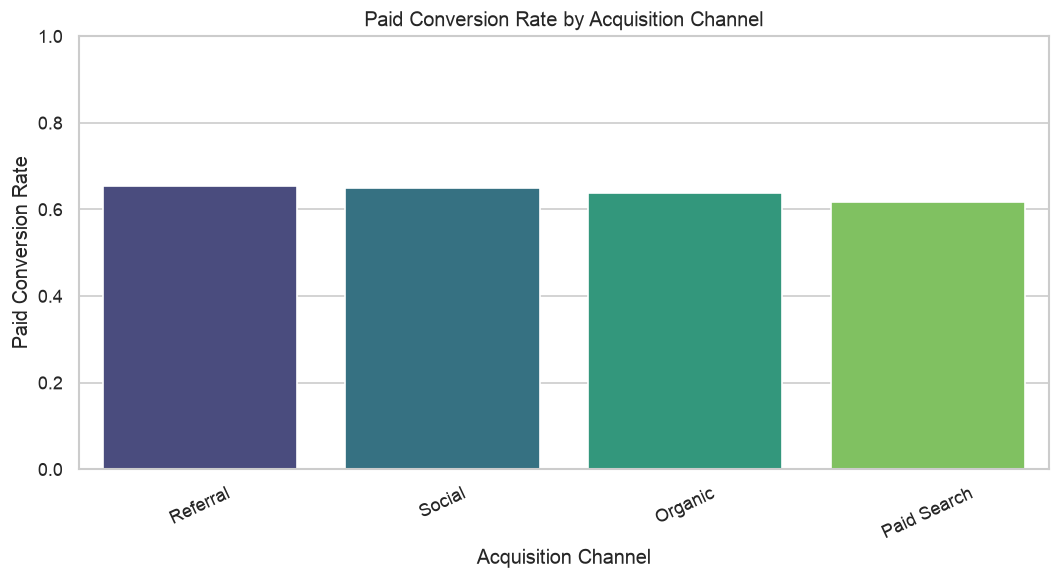

In [13]:
# ---------------------------------------------------------
# 3. Paid conversion by acquisition channel
# ---------------------------------------------------------

conversion_by_channel = (
    feature_frame
    .groupby("acquisition_channel")[
        "has_paid_purchase"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
    .reset_index(
        name="paid_conversion_rate"
    )
)

print(
    "\nPaid conversion rate by acquisition channel:"
)

print(
    conversion_by_channel.round(3)
)


plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=conversion_by_channel,
    x="acquisition_channel",
    y="paid_conversion_rate",
    hue="acquisition_channel",
    palette="viridis",
    legend=False
)

plt.title(
    "Paid Conversion Rate by Acquisition Channel"
)

plt.xlabel(
    "Acquisition Channel"
)

plt.ylabel(
    "Paid Conversion Rate"
)

plt.xticks(
    rotation=25
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()

### 2.4 Retention Signals


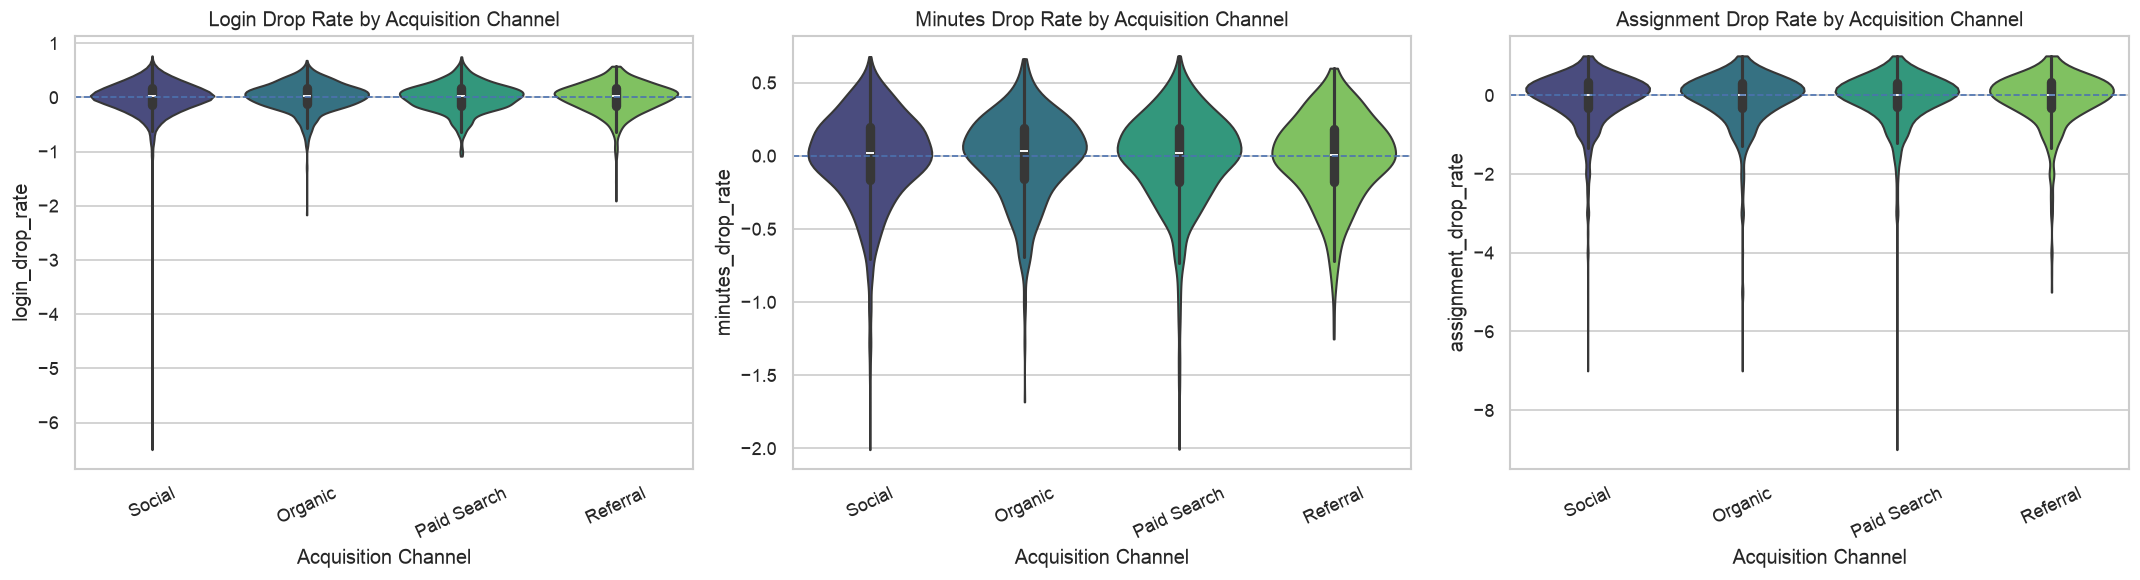

In [14]:
# ---------------------------------------------------------
# 4. Retention behavior by acquisition channel
# ---------------------------------------------------------

retention_metrics = [
    "login_drop_rate",
    "minutes_drop_rate",
    "assignment_drop_rate",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, metric in zip(
    axes,
    retention_metrics
):

    sns.violinplot(
        data=feature_frame,
        x="acquisition_channel",
        y=metric,
        hue="acquisition_channel",
        palette="viridis",
        legend=False,
        cut=0,
        ax=ax
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"{metric.replace('_', ' ').title()} by Acquisition Channel"
    )

    ax.set_xlabel(
        "Acquisition Channel"
    )

    ax.tick_params(
        axis="x",
        rotation=25
    )

plt.tight_layout()
plt.show()

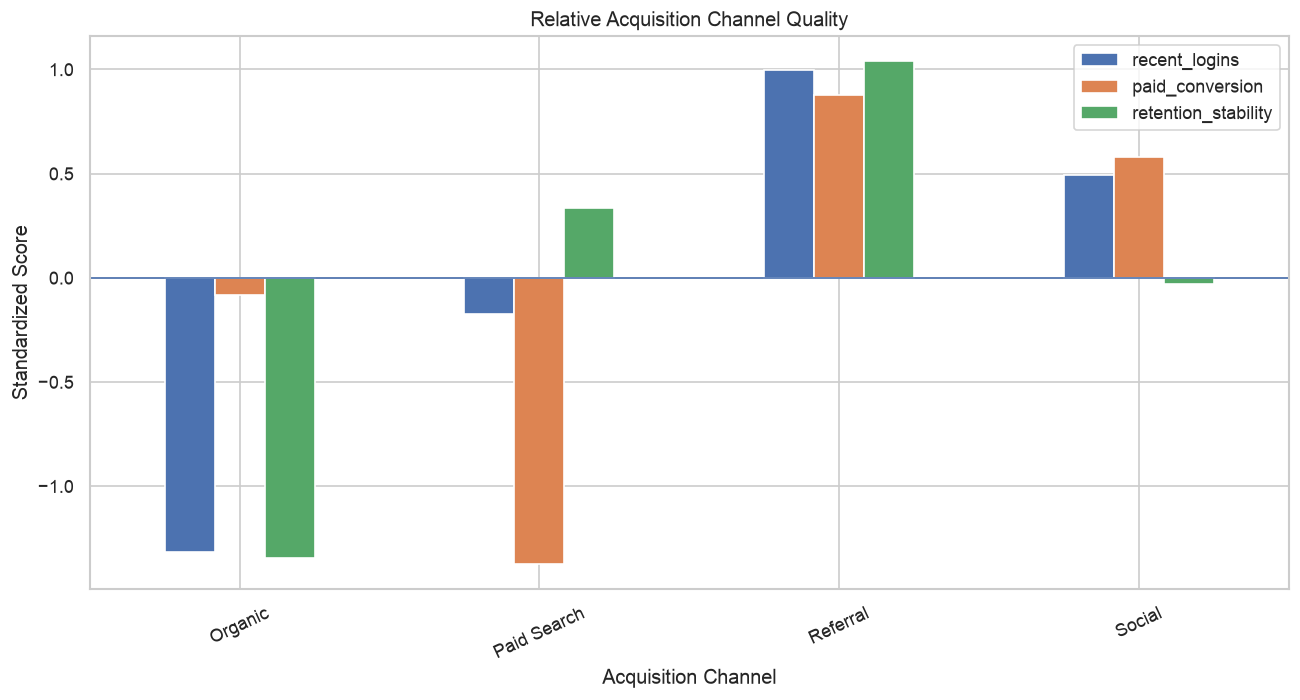

In [15]:
channel_comparison = (
    feature_frame
    .groupby("acquisition_channel")
    .agg(
        recent_logins=("recent_logins", "mean"),
        paid_conversion=("has_paid_purchase", "mean"),
        login_drop_rate=("login_drop_rate", "mean")
    )
)

channel_comparison[
    "retention_stability"
] = -channel_comparison[
    "login_drop_rate"
]

channel_comparison = channel_comparison[
    [
        "recent_logins",
        "paid_conversion",
        "retention_stability"
    ]
]

channel_normalized = (
    channel_comparison
    - channel_comparison.mean()
) / channel_comparison.std()

channel_normalized.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Relative Acquisition Channel Quality"
)

plt.xlabel(
    "Acquisition Channel"
)

plt.ylabel(
    "Standardized Score"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xticks(
    rotation=25
)

plt.tight_layout()
plt.show()

### 2.5 Service Interactions


## 3. Behavioral Driver Analysis


### 3.1 Acquisition → Customer Quality

Acquisition channel appears to be a secondary rather than dominant driver of downstream customer behavior. Engagement distributions are broadly similar across channels, suggesting that acquisition source alone does not strongly determine subsequent platform usage.

However, modest differences emerge across the customer funnel:

- **Paid Search** shows the highest paid conversion rate (67.4%), approximately 4.1 percentage points above Organic, suggesting relatively stronger conversion efficiency.
- **Referral** users exhibit slightly higher recent engagement and the most stable recent behavioral trends, with the lowest average login and watch-time decline.
- **Organic** users show somewhat weaker average conversion and behavioral stability, although substantial overlap remains across channel distributions.

Overall, acquisition channels appear to differ more in **conversion and retention characteristics** than in absolute engagement levels. These relationships should be tested further using multivariate analysis before treating acquisition channel as an independent behavioral driver.


### 3.2 Engagement → Monetization

This analysis tests whether more highly engaged students are more likely to convert into paying customers and make more purchases.



In [16]:
# =========================================================
# Engagement -> Monetization
# =========================================================

# Create engagement quartiles based on recent login activity
feature_frame["engagement_quartile"] = pd.qcut(
    feature_frame["recent_logins"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

engagement_monetization = (
    feature_frame
    .groupby(
        "engagement_quartile",
        observed=True
    )
    .agg(
        customers=("customer_id", "count"),
        avg_recent_logins=("recent_logins", "mean"),
        paid_conversion_rate=("has_paid_purchase", "mean"),
        avg_successful_transactions=("successful_transactions", "mean")
    )
)

print("\n=== Engagement -> Monetization ===")
print(engagement_monetization.round(3))


=== Engagement -> Monetization ===
                     customers  avg_recent_logins  paid_conversion_rate  \
engagement_quartile                                                       
Low                       1267             19.641                 0.552   
Medium-Low                1283             34.301                 0.648   
Medium-High               1242             49.513                 0.669   
High                      1208             71.723                 0.701   

                     avg_successful_transactions  
engagement_quartile                               
Low                                        0.830  
Medium-Low                                 1.051  
Medium-High                                1.121  
High                                       1.257  


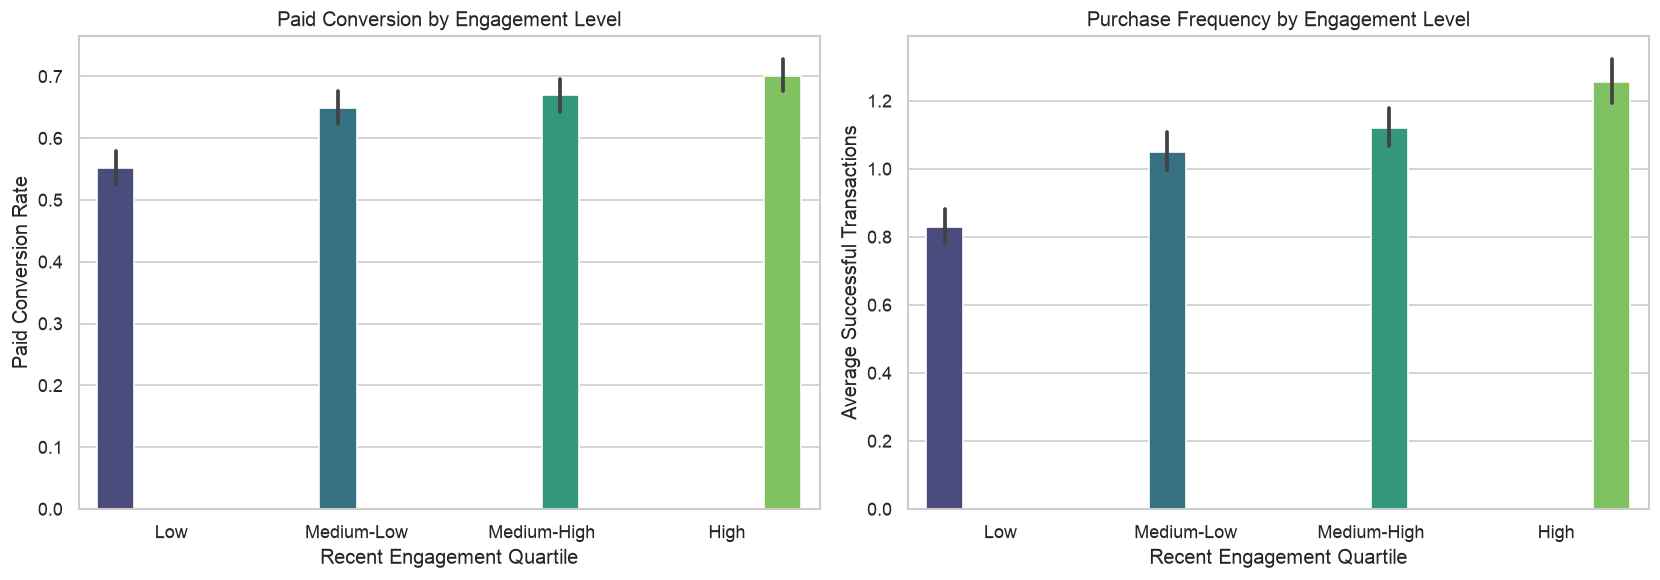

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=feature_frame,
    x="engagement_quartile",
    y="has_paid_purchase",
    hue="engagement_quartile",
    palette="viridis",
    legend=False,
    errorbar=("ci", 95),
    ax=axes[0]
)

axes[0].set_title(
    "Paid Conversion by Engagement Level"
)
axes[0].set_xlabel(
    "Recent Engagement Quartile"
)
axes[0].set_ylabel(
    "Paid Conversion Rate"
)


sns.barplot(
    data=feature_frame,
    x="engagement_quartile",
    y="successful_transactions",
    hue="engagement_quartile",
    palette="viridis",
    legend=False,
    errorbar=("ci", 95),
    ax=axes[1]
)

axes[1].set_title(
    "Purchase Frequency by Engagement Level"
)
axes[1].set_xlabel(
    "Recent Engagement Quartile"
)
axes[1].set_ylabel(
    "Average Successful Transactions"
)

plt.tight_layout()
plt.show()

In [18]:
engagement_metrics = [
    "recent_logins",
    "recent_minutes",
    "recent_assignments"
]

engagement_correlations = (
    feature_frame[
        engagement_metrics
        + [
            "has_paid_purchase",
            "successful_transactions"
        ]
    ]
    .corr()
    .loc[
        engagement_metrics,
        [
            "has_paid_purchase",
            "successful_transactions"
        ]
    ]
)

print(
    "\nEngagement vs monetization correlations:"
)

print(
    engagement_correlations.round(3)
)


Engagement vs monetization correlations:
                    has_paid_purchase  successful_transactions
recent_logins                   0.118                    0.157
recent_minutes                  0.108                    0.144
recent_assignments              0.110                    0.138


### Engagement and Monetization Findings

Recent engagement shows a clear positive association with customer monetization.

Paid conversion increases progressively from **57.8% among low-engagement customers to 70.7% among high-engagement customers**, a difference of approximately **12.9 percentage points**. Average successful transactions similarly increase from **0.88 to 1.28 purchases per customer** across the engagement quartiles.

Individual engagement measures—including recent logins, watch time, and assignment activity—show modest positive correlations with paid conversion and purchase frequency. However, the consistent monotonic pattern across engagement levels suggests that overall engagement is a meaningful behavioral indicator of downstream monetization.

These results support treating engagement as a core customer-health dimension while recognizing that purchase behavior is also influenced by factors beyond platform activity.

### 3.3 Behavioral Decline → Service Friction


In [19]:
# =========================================================
# Behavioral Decline -> Service Friction
# =========================================================

decline_metrics = [
    "login_drop_rate",
    "minutes_drop_rate",
    "assignment_drop_rate"
]

service_metrics = [
    "complaint_rate",
    "refund_rate",
    "resolved_issue_rate",
    "avg_resolution_hours",
    "avg_satisfaction_score"
]

decline_service_corr = (
    feature_frame[
        decline_metrics + service_metrics
    ]
    .corr()
    .loc[
        decline_metrics,
        service_metrics
    ]
)

print("\n=== Behavioral Decline -> Service Friction ===")
print(decline_service_corr.round(3))


=== Behavioral Decline -> Service Friction ===
                      complaint_rate  refund_rate  resolved_issue_rate  \
login_drop_rate               -0.008        0.085               -0.087   
minutes_drop_rate              0.002        0.055               -0.086   
assignment_drop_rate          -0.003        0.009               -0.007   

                      avg_resolution_hours  avg_satisfaction_score  
login_drop_rate                      0.068                  -0.021  
minutes_drop_rate                    0.069                  -0.020  
assignment_drop_rate                 0.012                   0.005  


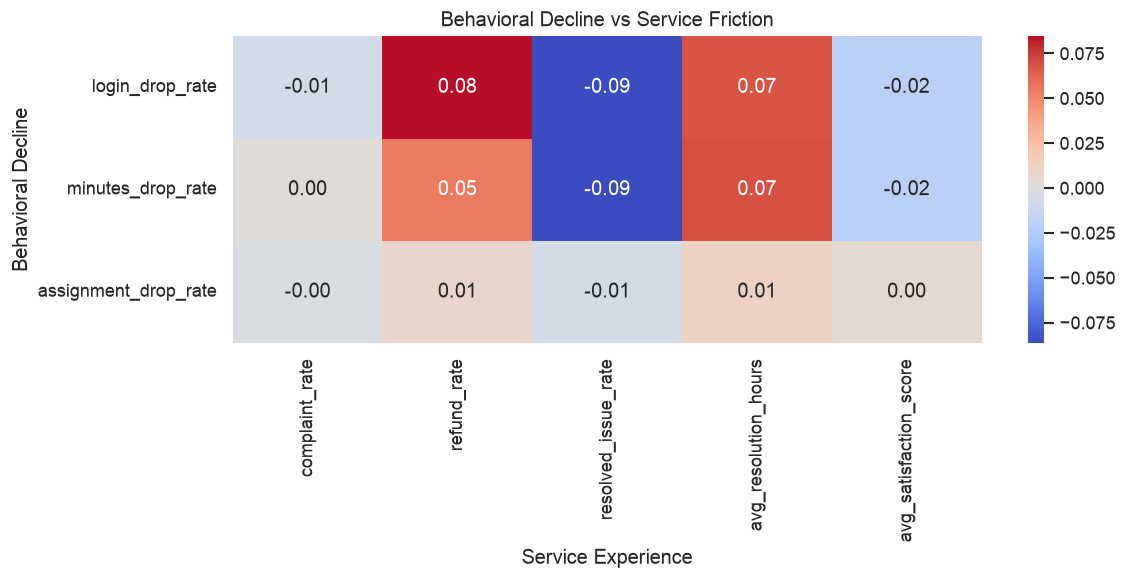

In [20]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    decline_service_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Behavioral Decline vs Service Friction"
)

plt.xlabel(
    "Service Experience"
)

plt.ylabel(
    "Behavioral Decline"
)

plt.tight_layout()
plt.show()

In [21]:
feature_frame["decline_group"] = pd.qcut(
    feature_frame["login_drop_rate"],
    q=4,
    labels=[
        "Improving / Stable",
        "Slight Decline",
        "Moderate Decline",
        "Strong Decline"
    ]
)

decline_service_summary = (
    feature_frame
    .groupby(
        "decline_group",
        observed=True
    )
    .agg(
        customers=("customer_id", "count"),
        avg_login_drop_rate=("login_drop_rate", "mean"),
        complaint_rate=("complaint_rate", "mean"),
        refund_rate=("refund_rate", "mean"),
        avg_resolution_rate=("resolved_issue_rate", "mean"),
        avg_resolution_hours=("avg_resolution_hours", "mean"),
        avg_satisfaction=("avg_satisfaction_score", "mean")
    )
)

print(
    "\n=== Service Experience by Behavioral Decline ==="
)

print(
    decline_service_summary.round(3)
)


=== Service Experience by Behavioral Decline ===
                    customers  avg_login_drop_rate  complaint_rate  \
decline_group                                                        
Improving / Stable       1278               -0.343           0.149   
Slight Decline           1222               -0.053           0.136   
Moderate Decline         1250                0.097           0.124   
Strong Decline           1250                0.309           0.141   

                    refund_rate  avg_resolution_rate  avg_resolution_hours  \
decline_group                                                                
Improving / Stable        0.026                0.629                30.542   
Slight Decline            0.030                0.617                31.211   
Moderate Decline          0.037                0.609                31.083   
Strong Decline            0.063                0.501                37.001   

                    avg_satisfaction  
decline_group        

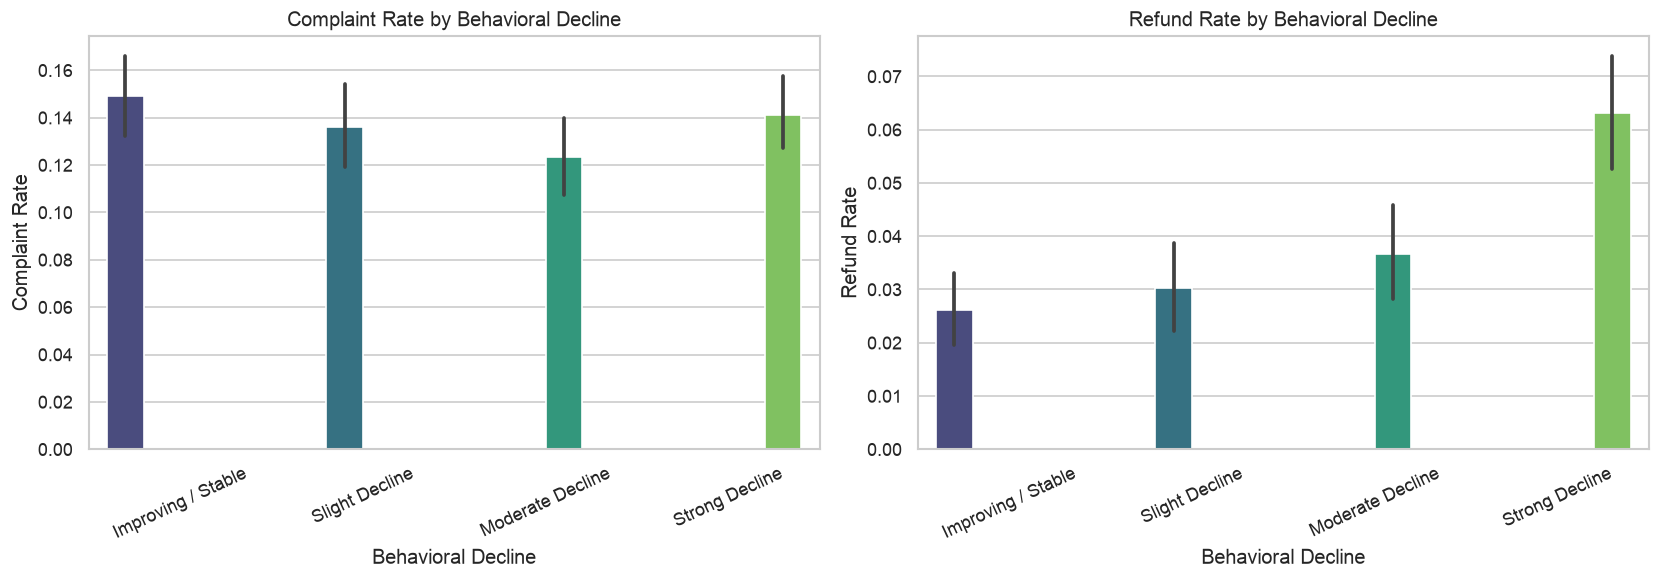

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=feature_frame,
    x="decline_group",
    y="complaint_rate",
    hue="decline_group",
    palette="viridis",
    legend=False,
    errorbar=("ci", 95),
    ax=axes[0]
)

axes[0].set_title(
    "Complaint Rate by Behavioral Decline"
)

axes[0].set_xlabel(
    "Behavioral Decline"
)

axes[0].set_ylabel(
    "Complaint Rate"
)

axes[0].tick_params(
    axis="x",
    rotation=25
)


sns.barplot(
    data=feature_frame,
    x="decline_group",
    y="refund_rate",
    hue="decline_group",
    palette="viridis",
    legend=False,
    errorbar=("ci", 95),
    ax=axes[1]
)

axes[1].set_title(
    "Refund Rate by Behavioral Decline"
)

axes[1].set_xlabel(
    "Behavioral Decline"
)

axes[1].set_ylabel(
    "Refund Rate"
)

axes[1].tick_params(
    axis="x",
    rotation=25
)

plt.tight_layout()
plt.show()

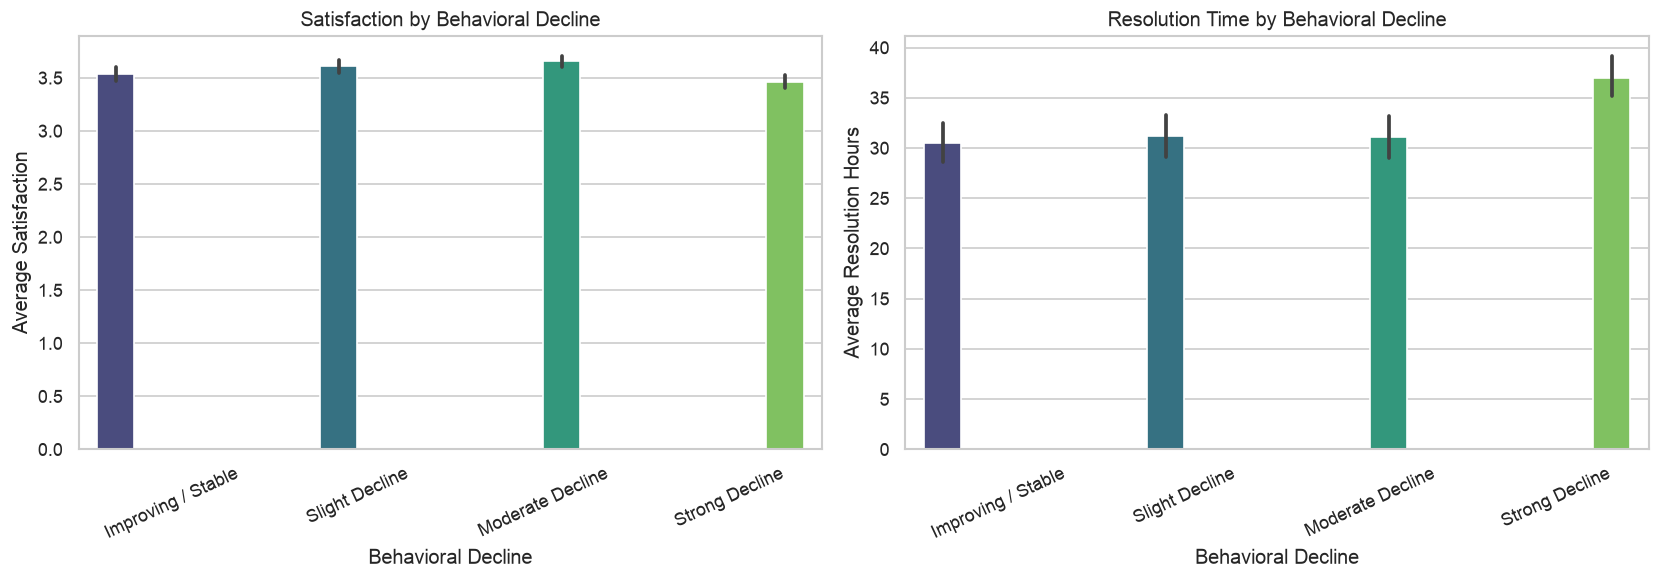

In [23]:
service_customers = feature_frame[
    feature_frame["has_service_interaction"] == 1
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=service_customers,
    x="decline_group",
    y="avg_satisfaction_score",
    hue="decline_group",
    palette="viridis",
    legend=False,
    errorbar=("ci", 95),
    ax=axes[0]
)

axes[0].set_title(
    "Satisfaction by Behavioral Decline"
)

axes[0].set_xlabel(
    "Behavioral Decline"
)

axes[0].set_ylabel(
    "Average Satisfaction"
)

axes[0].tick_params(
    axis="x",
    rotation=25
)


sns.barplot(
    data=service_customers,
    x="decline_group",
    y="avg_resolution_hours",
    hue="decline_group",
    palette="viridis",
    legend=False,
    errorbar=("ci", 95),
    ax=axes[1]
)

axes[1].set_title(
    "Resolution Time by Behavioral Decline"
)

axes[1].set_xlabel(
    "Behavioral Decline"
)

axes[1].set_ylabel(
    "Average Resolution Hours"
)

axes[1].tick_params(
    axis="x",
    rotation=25
)

plt.tight_layout()
plt.show()

## 4. Churn Prediction Problem Definition

The exploratory analysis suggests that customer risk is better reflected by changes in behavior over time than by static engagement levels alone.

In particular, customers exhibiting stronger behavioral decline tend to show greater service friction, including higher refund activity, lower issue-resolution rates, longer resolution times, and slightly lower satisfaction, although these relationships are modest overall.


                         Snapshot Date
                              │
                              ▼
          OBSERVATION         │          FUTURE
             WINDOW           │          WINDOW
                              │
Day -59 ───────────────────── 0 ───────────────────── Day +30
                              │
          Past 60 days        │       Next 30 days
                              │
        Candidate Features    │       Churn Outcome
                              │
        login activity        │   future behavioral
        watch time            │      deterioration
        assignments           │
        purchases             │   calibrated using
        complaints            │   multiple engagement
        refunds               │       dimensions
        service quality       │
        behavioral trends     │
                              │
                 NO INFORMATION CROSSOVER

The exact churn definition and deterioration thresholds are calibrated and validated in 02_churn_definition.ipynb.